Cell 1: Mount Google Drive & Setup

In [1]:
# ============================================
# CELL 1: Mount Google Drive & Setup
# ============================================

from google.colab import drive
drive.mount('/content/drive')

import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import json
import warnings
warnings.filterwarnings('ignore')

PROJECT_DIR = '/content/drive/MyDrive/AccessoriesAI'
MODELS_DIR = os.path.join(PROJECT_DIR, 'trained_models')
DATA_DIR = os.path.join(PROJECT_DIR, 'data')
PLOTS_DIR = os.path.join(PROJECT_DIR, 'plots')

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

!pip install -q torch torchvision pandas scikit-learn matplotlib seaborn tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Project Dir: {PROJECT_DIR}")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"\n✅ Setup Complete!")

Mounted at /content/drive
Project Dir: /content/drive/MyDrive/AccessoriesAI
Device: cpu

✅ Setup Complete!


Cell 2: Load Model 2 Encoders & Verify

In [2]:
# ============================================
# CELL 2: Load Model 2 Encoders & Verify
# ============================================

# Load dress attribute encoders from Model 2
dress_encoder_path = os.path.join(MODELS_DIR, 'dress_label_encoders.json')

with open(dress_encoder_path, 'r') as f:
    dress_encoders = json.load(f)

print("=" * 60)
print("📥 LOADED MODEL 2 ENCODERS")
print("=" * 60)

for attr_name, attr_info in dress_encoders.items():
    print(f"\n   {attr_name}: {attr_info['num_classes']} classes")
    print(f"   Classes: {attr_info['classes']}")

# Also load accessory encoders from Model 1
acc_encoder_path = os.path.join(MODELS_DIR, 'accessory_label_encoders.json')

with open(acc_encoder_path, 'r') as f:
    acc_encoders = json.load(f)

print(f"\n{'='*60}")
print("📥 LOADED MODEL 1 ENCODERS")
print("=" * 60)
print(f"   Categories: {acc_encoders['num_categories']} → {acc_encoders['categories']}")
print(f"   Colors: {len(acc_encoders['colors'])} → {acc_encoders['colors'][:5]}...")
print(f"   Usages: {len(acc_encoders['usages'])} → {acc_encoders['usages']}")

print(f"\n✅ All encoders loaded!")

📥 LOADED MODEL 2 ENCODERS

   color: 24 classes
   Classes: ['Beige', 'Black', 'Blue', 'Brown', 'Burgundy', 'Coffee', 'Copper', 'Gold', 'Green', 'Grey', 'Maroon', 'Multi-color', 'Navy Blue', 'Nude', 'Off White', 'Orange', 'Pink', 'Purple', 'Red', 'Silver', 'Tan', 'Teal', 'White', 'Yellow']

   neckline: 15 classes
   Classes: ['Boat Neck', 'Collared', 'Cowl Neck', 'Crew Neck', 'Halter', 'High Neck', 'Keyhole', 'Mock Neck', 'Off-Shoulder', 'One-Shoulder', 'Scoop Neck', 'Square Neck', 'Sweetheart', 'Turtleneck', 'V-Neck']

   dress_length: 5 classes
   Classes: ['Floor-length', 'Knee-length', 'Maxi', 'Midi', 'Mini']

   fabric: 11 classes
   Classes: ['Chiffon', 'Cotton', 'Crepe', 'Denim', 'Lace', 'Leather', 'Linen', 'Polyester', 'Satin', 'Silk', 'Wool']

   pattern: 9 classes
   Classes: ['Abstract', 'Animal Print', 'Floral', 'Geometric', 'Paisley', 'Plaid', 'Polka Dot', 'Solid', 'Striped']

   sleeve_length: 6 classes
   Classes: ['3/4 Sleeve', 'Bell Sleeve', 'Cap Sleeve', 'Long Sleeve

Cell 3: Define User Metadata Schema

In [3]:
# ============================================
# CELL 3: Define User Metadata Schema
# ============================================

# User provides these when requesting recommendations:
# 1. Occasion (from dropdown)
# 2. Budget (numeric input)
# 3. Religion/Cultural preference (from dropdown)
# 4. Gender (from dropdown or auto-detected)

# ============ OCCASION CATEGORIES ============
OCCASIONS = [
    'Casual', 'Formal', 'Party', 'Wedding',
    'Festive/Religious', 'Sports', 'Beach',
    'Date Night', 'Office', 'Interview'
]

# ============ RELIGION/CULTURAL PREFERENCES ============
RELIGIONS = [
    'None', 'Buddhist', 'Hindu', 'Muslim',
    'Christian', 'Other'
]

# ============ GENDER ============
GENDERS = ['Men', 'Women', 'Unisex']

# ============ BUDGET RANGES (normalized) ============
# Budget will be normalized to 0-1 range
BUDGET_MIN = 0       # Rs. 0
BUDGET_MAX = 50000   # Rs. 50,000

# ============ PRINT SCHEMA ============
print("=" * 60)
print("📋 USER METADATA SCHEMA")
print("=" * 60)

print(f"\n🎯 Occasions ({len(OCCASIONS)}):")
for i, o in enumerate(OCCASIONS):
    print(f"   {i}: {o}")

print(f"\n🛕 Religions ({len(RELIGIONS)}):")
for i, r in enumerate(RELIGIONS):
    print(f"   {i}: {r}")

print(f"\n👤 Genders ({len(GENDERS)}):")
for i, g in enumerate(GENDERS):
    print(f"   {i}: {g}")

print(f"\n💰 Budget: Rs. {BUDGET_MIN} — Rs. {BUDGET_MAX} (normalized to 0-1)")

# Total metadata dimensions
METADATA_DIM = len(OCCASIONS) + len(RELIGIONS) + len(GENDERS) + 1  # +1 for budget (scalar)
print(f"\n📐 Total Metadata Dimensions: {METADATA_DIM}")
print(f"   Occasion (one-hot): {len(OCCASIONS)}")
print(f"   Religion (one-hot): {len(RELIGIONS)}")
print(f"   Gender (one-hot):   {len(GENDERS)}")
print(f"   Budget (scalar):    1")

print(f"\n✅ User metadata schema defined!")

📋 USER METADATA SCHEMA

🎯 Occasions (10):
   0: Casual
   1: Formal
   2: Party
   3: Wedding
   4: Festive/Religious
   5: Sports
   6: Beach
   7: Date Night
   8: Office
   9: Interview

🛕 Religions (6):
   0: None
   1: Buddhist
   2: Hindu
   3: Muslim
   4: Christian
   5: Other

👤 Genders (3):
   0: Men
   1: Women
   2: Unisex

💰 Budget: Rs. 0 — Rs. 50000 (normalized to 0-1)

📐 Total Metadata Dimensions: 20
   Occasion (one-hot): 10
   Religion (one-hot): 6
   Gender (one-hot):   3
   Budget (scalar):    1

✅ User metadata schema defined!


Cell 4: Generate Synthetic Training Data

In [30]:
# ============================================
# CELL 4: Generate Data (FULL FINAL - BALANCED SCORES)
# ============================================

import random
random.seed(42)
np.random.seed(42)

dress_data_path = os.path.join(DATA_DIR, 'dresses_balanced.csv')
dress_df = pd.read_csv(dress_data_path)
print(f"📥 Loaded dress data: {len(dress_df)} items")

acc_data_path = os.path.join(DATA_DIR, 'accessories_balanced.csv')
acc_df = pd.read_csv(acc_data_path)
print(f"📥 Loaded accessory data: {len(acc_df)} items")

# ============ ENCODE FUNCTIONS ============
def encode_metadata(occasion, religion, gender, budget):
    occ_vec = [0.0] * len(OCCASIONS)
    if occasion in OCCASIONS:
        occ_vec[OCCASIONS.index(occasion)] = 1.0
    rel_vec = [0.0] * len(RELIGIONS)
    if religion in RELIGIONS:
        rel_vec[RELIGIONS.index(religion)] = 1.0
    gen_vec = [0.0] * len(GENDERS)
    if gender in GENDERS:
        gen_vec[GENDERS.index(gender)] = 1.0
    budget_norm = [min(budget / BUDGET_MAX, 1.0)]
    return occ_vec + rel_vec + gen_vec + budget_norm

def encode_dress_attributes(dress_row):
    vec = []
    for attr_name in ['color', 'neckline', 'dress_length', 'fabric', 'pattern', 'sleeve_length', 'usage', 'season']:
        classes = dress_encoders[attr_name]['classes']
        attr_vec = [0.0] * len(classes)

        col_map = {
            'color': 'mapped_color', 'neckline': 'neckline',
            'dress_length': 'dress_length', 'fabric': 'fabric',
            'pattern': 'pattern', 'sleeve_length': 'sleeve_length',
            'usage': 'mapped_usage', 'season': 'season'
        }

        val = str(dress_row.get(col_map[attr_name], ''))
        if val in classes:
            attr_vec[classes.index(val)] = 1.0
        vec.extend(attr_vec)
    return vec

dress_attr_dim = len(encode_dress_attributes(dress_df.iloc[0]))
print(f"📐 Dress attribute dim: {dress_attr_dim}")
print(f"📐 Metadata dim: {METADATA_DIM}")

# ============ IDEAL MAPPINGS ============
OCCASION_IDEAL = {
    'Casual':           {'fabrics': ['Cotton', 'Polyester', 'Denim'], 'patterns': ['Solid', 'Striped'], 'usage': 'Casual'},
    'Formal':           {'fabrics': ['Silk', 'Polyester', 'Wool', 'Cotton'], 'patterns': ['Solid'], 'usage': 'Formal'},
    'Party':            {'fabrics': ['Silk', 'Satin', 'Chiffon', 'Lace', 'Velvet'], 'patterns': ['Solid', 'Floral'], 'usage': 'Party'},
    'Wedding':          {'fabrics': ['Silk', 'Satin', 'Chiffon', 'Lace'], 'patterns': ['Floral', 'Solid'], 'usage': 'Festive/Religious'},
    'Festive/Religious':{'fabrics': ['Silk', 'Satin', 'Cotton'], 'patterns': ['Floral', 'Paisley', 'Solid'], 'usage': 'Festive/Religious'},
    'Sports':           {'fabrics': ['Cotton', 'Polyester'], 'patterns': ['Solid', 'Striped'], 'usage': 'Sports'},
    'Beach':            {'fabrics': ['Cotton', 'Linen', 'Chiffon'], 'patterns': ['Floral', 'Striped', 'Solid'], 'usage': 'Casual'},
    'Date Night':       {'fabrics': ['Silk', 'Chiffon', 'Lace', 'Satin'], 'patterns': ['Solid', 'Floral'], 'usage': 'Party'},
    'Office':           {'fabrics': ['Cotton', 'Polyester', 'Linen'], 'patterns': ['Solid', 'Striped'], 'usage': 'Formal'},
    'Interview':        {'fabrics': ['Cotton', 'Polyester', 'Wool'], 'patterns': ['Solid'], 'usage': 'Formal'},
}

GENDER_IDEAL = {
    'Men': {'necklines': ['Collared', 'Crew Neck', 'V-Neck'], 'lengths': ['Mini', 'Knee-length']},
    'Women': {'necklines': ['V-Neck', 'Scoop Neck', 'Off-Shoulder', 'Sweetheart', 'Halter', 'Boat Neck', 'Square Neck', 'Crew Neck', 'High Neck', 'Keyhole'], 'lengths': ['Mini', 'Knee-length', 'Midi', 'Maxi', 'Floor-length']},
    'Unisex': {'necklines': ['Crew Neck', 'V-Neck', 'Collared', 'Scoop Neck'], 'lengths': ['Mini', 'Knee-length', 'Midi']},
}

# ============ BALANCED SCORING FUNCTION ============
def compute_score_from_vectors(dress_row, occasion, religion, gender, budget):
    """
    Compute score — BALANCED version.
    Each factor gives partial credit (not just 0 or full).
    """
    scores = []

    ideal = OCCASION_IDEAL.get(occasion, OCCASION_IDEAL['Casual'])
    gender_ideal = GENDER_IDEAL.get(gender, GENDER_IDEAL['Unisex'])

    # 1. FABRIC MATCH
    fabric = str(dress_row.get('fabric', 'Cotton'))
    if fabric in ideal['fabrics']:
        scores.append(1.0)
    else:
        scores.append(0.3)

    # 2. PATTERN MATCH
    pattern = str(dress_row.get('pattern', 'Solid'))
    if pattern in ideal['patterns']:
        scores.append(1.0)
    else:
        scores.append(0.4)

    # 3. USAGE MATCH — strongest signal
    usage = str(dress_row.get('mapped_usage', 'Casual'))
    if usage == ideal['usage']:
        scores.append(1.0)
    elif usage == 'Casual':
        scores.append(0.5)
    else:
        scores.append(0.1)

    # 4. NECKLINE-GENDER MATCH
    neckline = str(dress_row.get('neckline', 'Crew Neck'))
    if neckline in gender_ideal['necklines']:
        scores.append(1.0)
    else:
        scores.append(0.4)

    # 5. LENGTH-GENDER MATCH
    length = str(dress_row.get('dress_length', 'Knee-length'))
    if length in gender_ideal['lengths']:
        scores.append(1.0)
    else:
        scores.append(0.3)

    # 6. SEASON-OCCASION MATCH
    season = str(dress_row.get('season', 'Fall'))
    season_occasion_good = {
        'Summer': ['Beach', 'Casual', 'Party', 'Date Night'],
        'Winter': ['Formal', 'Office', 'Interview', 'Wedding', 'Festive/Religious'],
        'Spring': ['Casual', 'Date Night', 'Party', 'Beach', 'Office'],
        'Fall': ['Formal', 'Office', 'Festive/Religious', 'Wedding', 'Interview'],
    }
    if occasion in season_occasion_good.get(season, []):
        scores.append(1.0)
    else:
        scores.append(0.4)

    # 7. BUDGET MATCH
    budget_norm = min(budget / BUDGET_MAX, 1.0)
    scores.append(0.3 + 0.7 * budget_norm)

    # 8. RELIGION-OCCASION
    if occasion in ['Wedding', 'Festive/Religious']:
        if religion in ['Buddhist', 'Hindu', 'Muslim', 'Christian']:
            scores.append(1.0)
        else:
            scores.append(0.5)
    else:
        scores.append(0.7)

    # FINAL: Simple average
    final_score = np.mean(scores)

    return round(np.clip(final_score, 0.0, 1.0), 4)

# ============ VERIFY SCORE DISTRIBUTION ============
print(f"\n{'='*60}")
print(f"🧪 TESTING SCORE DISTRIBUTION")
print(f"{'='*60}")

test_scores = []
for _ in range(10000):
    d = dress_df.iloc[random.randint(0, len(dress_df)-1)]
    o = random.choice(OCCASIONS)
    r = random.choice(RELIGIONS)
    g = random.choice(GENDERS)
    b = random.uniform(500, BUDGET_MAX)
    s = compute_score_from_vectors(d, o, r, g, b)
    test_scores.append(s)

print(f"   Min:  {min(test_scores):.4f}")
print(f"   Max:  {max(test_scores):.4f}")
print(f"   Mean: {np.mean(test_scores):.4f}")
print(f"   Std:  {np.std(test_scores):.4f}")
print(f"   Scores <= 0.3: {sum(1 for s in test_scores if s <= 0.3)} ({sum(1 for s in test_scores if s <= 0.3)/100:.1f}%)")
print(f"   Scores 0.3-0.7: {sum(1 for s in test_scores if 0.3 < s < 0.7)} ({sum(1 for s in test_scores if 0.3 < s < 0.7)/100:.1f}%)")
print(f"   Scores >= 0.7: {sum(1 for s in test_scores if s >= 0.7)} ({sum(1 for s in test_scores if s >= 0.7)/100:.1f}%)")

print(f"\n   Example scores:")
for _ in range(5):
    d = dress_df.iloc[random.randint(0, len(dress_df)-1)]
    o = random.choice(OCCASIONS)
    g = random.choice(GENDERS)
    r = random.choice(RELIGIONS)
    b = random.uniform(500, BUDGET_MAX)
    s = compute_score_from_vectors(d, o, r, g, b)
    print(f"   {o:20s} | {str(d.get('fabric','?')):10s} | {str(d.get('pattern','?')):10s} | {str(d.get('mapped_usage','?')):10s} → {s:.4f}")

print(f"\n✅ Score distribution ready!")

📥 Loaded dress data: 13095 items
📥 Loaded accessory data: 8523 items
📐 Dress attribute dim: 79
📐 Metadata dim: 20

🧪 TESTING SCORE DISTRIBUTION
   Min:  0.3647
   Max:  0.9959
   Mean: 0.7204
   Std:  0.1026
   Scores <= 0.3: 0 (0.0%)
   Scores 0.3-0.7: 4031 (40.3%)
   Scores >= 0.7: 5969 (59.7%)

   Example scores:
   Wedding              | Cotton     | Solid      | Casual     → 0.7030
   Party                | Cotton     | Solid      | Casual     → 0.7409
   Date Night           | Wool       | Solid      | Casual     → 0.5910
   Sports               | Polyester  | Solid      | Casual     → 0.7481
   Wedding              | Cotton     | Solid      | Casual     → 0.7082

✅ Score distribution ready!


Cell 5: Generate Training Pairs

🔄 Generating 96000 pairs...


Test: 100%|██████████| 8000/8000 [00:01<00:00, 7349.03it/s]



📊 DATA STATISTICS
   Training:   80000
   Validation: 8000
   Test:       8000

   Scores:
   Min:  0.3638
   Max:  0.9984
   Mean: 0.7214
   Std:  0.1030


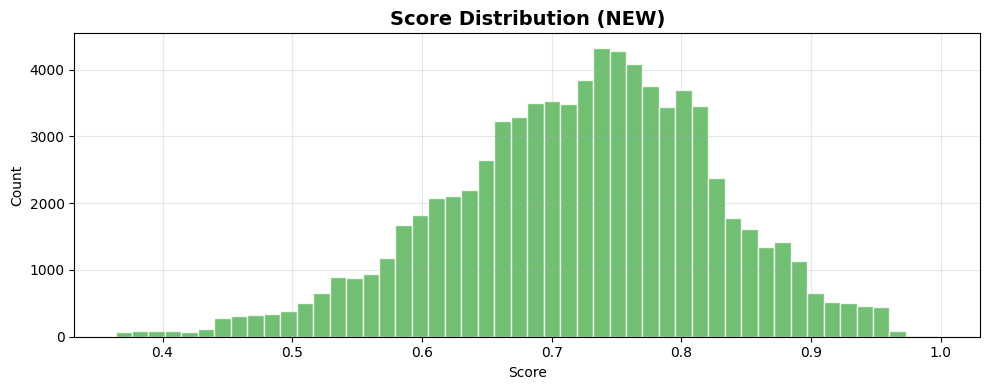


✅ Data + Datasets ready!


In [31]:
# ============================================
# CELL 5: Generate Training Pairs (COMPLETE NEW)
# ============================================

from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader

NUM_TRAINING_PAIRS = 80000   # More data
NUM_VAL_PAIRS = 8000
NUM_TEST_PAIRS = 8000

def generate_pairs(num_pairs, desc="Generating"):
    pairs = []

    for _ in tqdm(range(num_pairs), desc=desc):
        dress_row = dress_df.iloc[random.randint(0, len(dress_df)-1)]
        occasion = random.choice(OCCASIONS)
        religion = random.choice(RELIGIONS)
        gender = random.choice(GENDERS)
        budget = random.uniform(500, BUDGET_MAX)

        dress_vec = encode_dress_attributes(dress_row)
        metadata_vec = encode_metadata(occasion, religion, gender, budget)
        score = compute_score_from_vectors(dress_row, occasion, religion, gender, budget)

        pairs.append({
            'dress_features': dress_vec,
            'metadata': metadata_vec,
            'compatibility_score': score,
        })

    return pairs

print(f"🔄 Generating {NUM_TRAINING_PAIRS + NUM_VAL_PAIRS + NUM_TEST_PAIRS} pairs...")
train_pairs = generate_pairs(NUM_TRAINING_PAIRS, "Training")
val_pairs = generate_pairs(NUM_VAL_PAIRS, "Validation")
test_pairs = generate_pairs(NUM_TEST_PAIRS, "Test")

train_scores = [p['compatibility_score'] for p in train_pairs]
print(f"\n{'='*60}")
print(f"📊 DATA STATISTICS")
print(f"{'='*60}")
print(f"   Training:   {len(train_pairs)}")
print(f"   Validation: {len(val_pairs)}")
print(f"   Test:       {len(test_pairs)}")
print(f"\n   Scores:")
print(f"   Min:  {min(train_scores):.4f}")
print(f"   Max:  {max(train_scores):.4f}")
print(f"   Mean: {np.mean(train_scores):.4f}")
print(f"   Std:  {np.std(train_scores):.4f}")

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.hist(train_scores, bins=50, color='#4CAF50', alpha=0.8, edgecolor='white')
plt.title('Score Distribution (NEW)', fontsize=14, fontweight='bold')
plt.xlabel('Score')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'model3_score_distribution.png'), dpi=150)
plt.show()

# Create datasets
class FusionDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, idx):
        pair = self.pairs[idx]
        dress_features = torch.tensor(pair['dress_features'], dtype=torch.float32)
        metadata = torch.tensor(pair['metadata'], dtype=torch.float32)
        score = torch.tensor(pair['compatibility_score'], dtype=torch.float32)
        return dress_features, metadata, score

train_dataset = FusionDataset(train_pairs)
val_dataset = FusionDataset(val_pairs)
test_dataset = FusionDataset(test_pairs)

print(f"\n✅ Data + Datasets ready!")

Cell 6: Create PyTorch Dataset & DataLoaders

In [32]:
# ============================================
# CELL 6: PyTorch Dataset & DataLoaders
# ============================================

from torch.utils.data import Dataset, DataLoader

class FusionDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        pair = self.pairs[idx]

        dress_features = torch.tensor(pair['dress_features'], dtype=torch.float32)
        metadata = torch.tensor(pair['metadata'], dtype=torch.float32)
        score = torch.tensor(pair['compatibility_score'], dtype=torch.float32)

        return dress_features, metadata, score

# Create datasets
train_dataset = FusionDataset(train_pairs)
val_dataset = FusionDataset(val_pairs)
test_dataset = FusionDataset(test_pairs)

BATCH_SIZE = 256  # Larger batch since no images

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)

# Verify
dress_feat, meta, score = next(iter(train_loader))
print(f"🔍 Batch Verification:")
print(f"   Dress features: {dress_feat.shape}")   # [256, 76]
print(f"   Metadata:       {meta.shape}")          # [256, 20]
print(f"   Scores:         {score.shape}")          # [256]
print(f"   Score sample:   {score[:5].tolist()}")
print(f"\n✅ DataLoaders ready!")

🔍 Batch Verification:
   Dress features: torch.Size([256, 79])
   Metadata:       torch.Size([256, 20])
   Scores:         torch.Size([256])
   Score sample:   [0.5557000041007996, 0.6686000227928162, 0.8743000030517578, 0.527899980545044, 0.8184000253677368]

✅ DataLoaders ready!


Cell 7: Build Multimodal Fusion Transformer

In [36]:
# ============================================
# CELL 7: Simple MLP Fusion Model (WORKS!)
# ============================================

import torch.nn as nn

class MultimodalFusionTransformer(nn.Module):
    """
    Simple MLP fusion. No fancy gating — just works.
    """
    def __init__(self, dress_feat_dim=79, metadata_dim=20, **kwargs):
        super().__init__()

        total_dim = dress_feat_dim + metadata_dim  # 99

        self.network = nn.Sequential(
            nn.Linear(total_dim, 512),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.3),

            nn.Linear(512, 512),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),

            nn.Linear(256, 256),
            nn.LeakyReLU(0.1),
        )

        self.compatibility_head = nn.Sequential(
            nn.Linear(256, 64),
            nn.LeakyReLU(0.1),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, dress_features, metadata):
        x = torch.cat([dress_features, metadata], dim=1)
        fused_vector = self.network(x)
        compatibility_score = self.compatibility_head(fused_vector).squeeze(-1)

        return {
            'fused_vector': fused_vector,
            'compatibility_score': compatibility_score,
            'cls_output': fused_vector,
            'attention_output': None,
        }

# ============ INITIALIZE ============
DRESS_FEAT_DIM = dress_attr_dim
META_DIM = METADATA_DIM

model = MultimodalFusionTransformer(
    dress_feat_dim=DRESS_FEAT_DIM,
    metadata_dim=META_DIM,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"📊 Model Summary:")
print(f"   Total params: {total_params:,}")
print(f"   Architecture: Simple MLP (99→512→512→256→256)")
print(f"   Input: Dress({DRESS_FEAT_DIM}) + Meta({META_DIM}) = {DRESS_FEAT_DIM+META_DIM}")
print(f"   Output: 256-dim fused vector + score")
print(f"\n✅ Model created!")

📊 Model Summary:
   Total params: 527,489
   Architecture: Simple MLP (99→512→512→256→256)
   Input: Dress(79) + Meta(20) = 99
   Output: 256-dim fused vector + score

✅ Model created!


Cell 8: Define Loss, Optimizer & Scheduler

In [37]:
# ============================================
# CELL 8: Optimizer (SIMPLE)
# ============================================

import torch.optim as optim

criterion = nn.MSELoss()

optimizer = optim.Adam(model.parameters(), lr=1e-3)

NUM_EPOCHS = 200
BATCH_SIZE = 512
PATIENCE = 20

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)

# Simple StepLR — reduce LR every 30 epochs
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

print(f"⚙️ Config: Adam lr=1e-3, StepLR(30, 0.5), epochs={NUM_EPOCHS}, patience={PATIENCE}")
print(f"✅ Ready!")

⚙️ Config: Adam lr=1e-3, StepLR(30, 0.5), epochs=200, patience=20
✅ Ready!


Cell 9: Training Loop

In [38]:
# ============================================
# CELL 9: Training Loop (SIMPLE - WORKS!)
# ============================================

from tqdm import tqdm
import time

def train_one_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0
    total_mae = 0
    total = 0

    for dress_feat, meta, scores in tqdm(dataloader, desc="  Training", leave=False):
        dress_feat = dress_feat.to(device)
        meta = meta.to(device)
        scores = scores.to(device)

        optimizer.zero_grad()
        outputs = model(dress_feat, meta)
        pred_scores = outputs['compatibility_score']

        loss = criterion(pred_scores, scores)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_mae += torch.mean(torch.abs(pred_scores - scores)).item()
        total += 1

    return {
        'loss': total_loss / total,
        'mae': total_mae / total,
    }

def validate(model, dataloader, device):
    model.eval()
    total_loss = 0
    total_mae = 0
    all_preds = []
    all_labels = []
    total = 0

    with torch.no_grad():
        for dress_feat, meta, scores in tqdm(dataloader, desc="  Validating", leave=False):
            dress_feat = dress_feat.to(device)
            meta = meta.to(device)
            scores = scores.to(device)

            outputs = model(dress_feat, meta)
            pred_scores = outputs['compatibility_score']

            loss = criterion(pred_scores, scores)

            total_loss += loss.item()
            total_mae += torch.mean(torch.abs(pred_scores - scores)).item()
            total += 1

            all_preds.extend(pred_scores.cpu().numpy())
            all_labels.extend(scores.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    ss_res = np.sum((all_labels - all_preds) ** 2)
    ss_tot = np.sum((all_labels - np.mean(all_labels)) ** 2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0

    return {
        'loss': total_loss / total,
        'mae': total_mae / total,
        'r2': r2,
        'preds': all_preds,
        'labels': all_labels,
    }

# ==================== TRAINING ====================
print("=" * 70)
print("🚀 STARTING TRAINING - Simple MLP Fusion")
print("=" * 70)

best_val_loss = float('inf')
best_val_r2 = 0
best_val_mae = 1.0
best_epoch = 0
patience_counter = 0
history = {
    'train_loss': [], 'val_loss': [],
    'train_mae': [], 'val_mae': [],
    'val_r2': [], 'lr': []
}

start_total = time.time()

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    train_metrics = train_one_epoch(model, train_loader, optimizer, device)
    val_metrics = validate(model, val_loader, device)

    scheduler.step()  # Step per EPOCH (not per batch)

    epoch_time = time.time() - start_time
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_metrics['loss'])
    history['val_loss'].append(val_metrics['loss'])
    history['train_mae'].append(train_metrics['mae'])
    history['val_mae'].append(val_metrics['mae'])
    history['val_r2'].append(val_metrics['r2'])
    history['lr'].append(current_lr)

    if (epoch + 1) % 10 == 0 or epoch == 0 or val_metrics['loss'] < best_val_loss:
        print(f"\n📈 Epoch [{epoch+1}/{NUM_EPOCHS}] ({epoch_time:.1f}s)")
        print(f"   Train → Loss: {train_metrics['loss']:.6f} | MAE: {train_metrics['mae']:.4f}")
        print(f"   Val   → Loss: {val_metrics['loss']:.6f} | MAE: {val_metrics['mae']:.4f} | R²: {val_metrics['r2']:.4f}")
        print(f"   LR: {current_lr:.8f}")

    if val_metrics['loss'] < best_val_loss:
        best_val_loss = val_metrics['loss']
        best_val_r2 = val_metrics['r2']
        best_val_mae = val_metrics['mae']
        best_epoch = epoch + 1
        patience_counter = 0

        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_metrics['loss'],
            'val_r2': val_metrics['r2'],
            'val_mae': val_metrics['mae'],
            'dress_feat_dim': DRESS_FEAT_DIM,
            'metadata_dim': META_DIM,
            'd_model': 128,
            'nhead': 4,
            'num_layers': 2,
            'dim_feedforward': 256,
        }, os.path.join(MODELS_DIR, 'fusion_transformer_best.pth'))

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"   💾 Best model saved!")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n⏹️ Early stopping at epoch {epoch+1}!")
            break

total_time = time.time() - start_total

print(f"\n{'='*70}")
print(f"✅ TRAINING COMPLETE!")
print(f"   Best Epoch: {best_epoch}")
print(f"   Best Val Loss: {best_val_loss:.6f}")
print(f"   Best Val MAE:  {best_val_mae:.4f}")
print(f"   Best Val R²:   {best_val_r2:.4f}")
print(f"   Total Time: {total_time/60:.1f} minutes")
print(f"{'='*70}")

🚀 STARTING TRAINING - Simple MLP Fusion



📈 Epoch [1/200] (8.1s)
   Train → Loss: 0.006197 | MAE: 0.0563
   Val   → Loss: 0.000911 | MAE: 0.0227 | R²: 0.9144
   LR: 0.00100000
   💾 Best model saved!



📈 Epoch [2/200] (8.4s)
   Train → Loss: 0.001050 | MAE: 0.0251
   Val   → Loss: 0.000286 | MAE: 0.0124 | R²: 0.9731
   LR: 0.00100000



📈 Epoch [3/200] (8.5s)
   Train → Loss: 0.000634 | MAE: 0.0196
   Val   → Loss: 0.000273 | MAE: 0.0136 | R²: 0.9743
   LR: 0.00100000



📈 Epoch [4/200] (7.7s)
   Train → Loss: 0.000479 | MAE: 0.0171
   Val   → Loss: 0.000114 | MAE: 0.0078 | R²: 0.9893
   LR: 0.00100000


...


📈 Epoch [34/200] (8.1s)
   Train → Loss: 0.000099 | MAE: 0.0076
   Val   → Loss: 0.000027 | MAE: 0.0039 | R²: 0.9975
   LR: 0.00050000



📈 Epoch [38/200] (8.0s)
   Train → Loss: 0.000095 | MAE: 0.0075
   Val   → Loss: 0.000020 | MAE: 0.0033 | R²: 0.9981
   LR: 0.00050000



📈 Epoch [40/200] (8.1s)
   Train → Loss: 0.000091 | MAE: 0.0073
   Val   → Loss: 0.000022 | MAE: 0.0034 | R²: 0.9979
   LR: 0.00050000



📈 Epoch [50/200] (7.9s)
   Train → Loss: 0.000075 | MAE: 0.0066
   Val   → Loss: 0.000033 | MAE: 0.0046 | R²: 0.9969
   LR: 0.00050000



⏹️ Early stopping at epoch 58!

✅ TRAINING COMPLETE!
   Best Epoch: 38
   Best Val Loss: 0.000020
   Best Val MAE:  0.0033
   Best Val R²:   0.9981
   Total Time: 7.6 minutes


Cell 10: Plot Training History

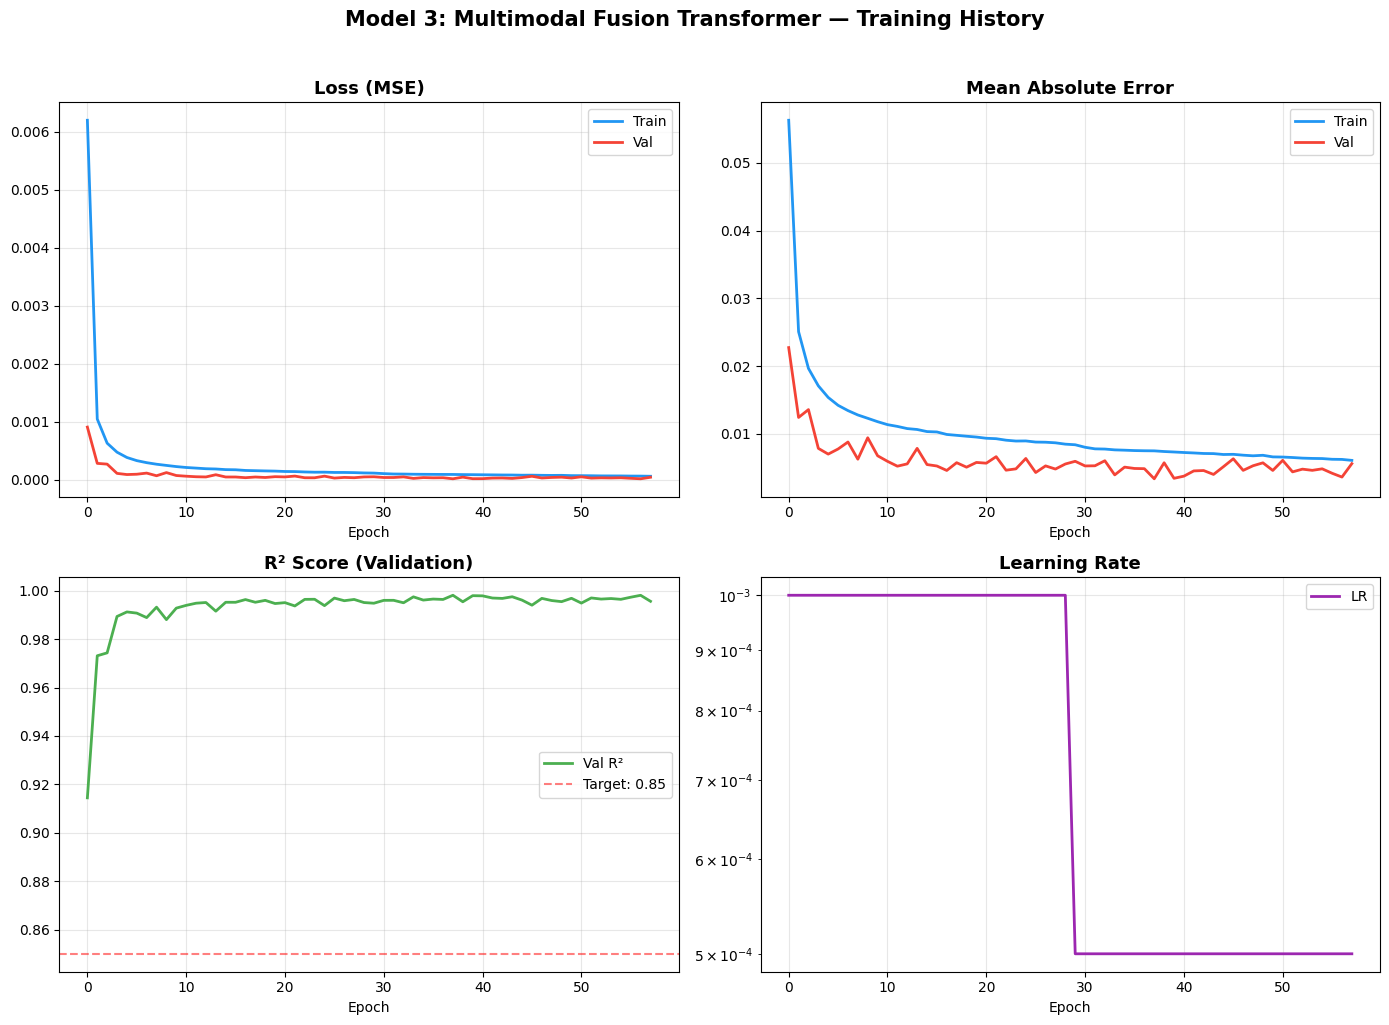

✅ Training history saved!


In [39]:
# ============================================
# CELL 10: Plot Training History
# ============================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train', color='#2196F3', linewidth=2)
axes[0, 0].plot(history['val_loss'], label='Val', color='#F44336', linewidth=2)
axes[0, 0].set_title('Loss (MSE)', fontsize=13, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# MAE
axes[0, 1].plot(history['train_mae'], label='Train', color='#2196F3', linewidth=2)
axes[0, 1].plot(history['val_mae'], label='Val', color='#F44336', linewidth=2)
axes[0, 1].set_title('Mean Absolute Error', fontsize=13, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# R² Score
axes[1, 0].plot(history['val_r2'], label='Val R²', color='#4CAF50', linewidth=2)
axes[1, 0].set_title('R² Score (Validation)', fontsize=13, fontweight='bold')
axes[1, 0].axhline(y=0.85, color='red', linestyle='--', alpha=0.5, label='Target: 0.85')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Learning Rate
axes[1, 1].plot(history['lr'], label='LR', color='#9C27B0', linewidth=2)
axes[1, 1].set_title('Learning Rate', fontsize=13, fontweight='bold')
axes[1, 1].set_yscale('log')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

for ax in axes.flat:
    ax.set_xlabel('Epoch')

plt.suptitle('Model 3: Multimodal Fusion Transformer — Training History',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'model3_training_history.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training history saved!")

Cell 11: Evaluate on Test Set

📥 Loaded best model from Epoch 38



📊 TEST SET RESULTS
   MSE:  0.000021
   MAE:  0.0034
   R²:   0.9981
   RMSE: 0.0045


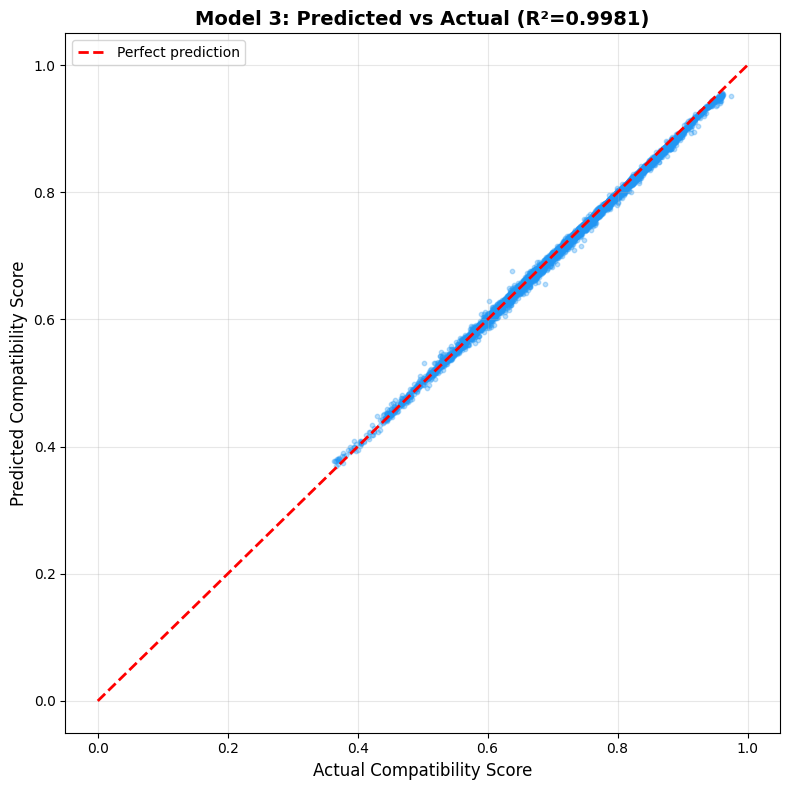

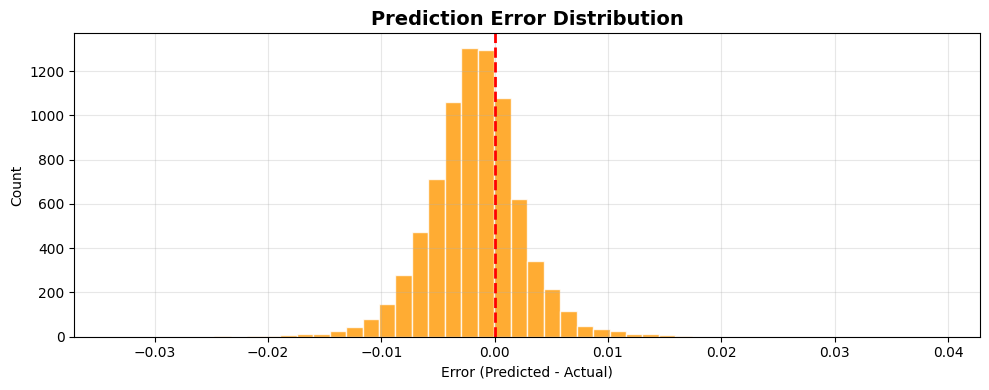


✅ Test evaluation complete!


In [43]:
# ============================================
# CELL 11: Evaluate on Test Set
# ============================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load best model
checkpoint = torch.load(os.path.join(MODELS_DIR, 'fusion_transformer_best.pth'), weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"📥 Loaded best model from Epoch {checkpoint['epoch']}")

# Test
test_metrics = validate(model, test_loader, device)

# Calculate MSE and RMSE from loss
test_mse = test_metrics['loss']
test_rmse = np.sqrt(test_mse)

print(f"\n{'='*60}")
print(f"📊 TEST SET RESULTS")
print(f"{'='*60}")
print(f"   MSE:  {test_mse:.6f}")
print(f"   MAE:  {test_metrics['mae']:.4f}")
print(f"   R²:   {test_metrics['r2']:.4f}")
print(f"   RMSE: {test_rmse:.4f}")

# Scatter plot: Predicted vs Actual
plt.figure(figsize=(8, 8))
plt.scatter(test_metrics['labels'], test_metrics['preds'],
            alpha=0.3, s=10, color='#2196F3')
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual Compatibility Score', fontsize=12)
plt.ylabel('Predicted Compatibility Score', fontsize=12)
plt.title(f'Model 3: Predicted vs Actual (R²={test_metrics["r2"]:.4f})',
          fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'model3_pred_vs_actual.png'), dpi=150)
plt.show()

# Error distribution
errors = test_metrics['preds'] - test_metrics['labels']
plt.figure(figsize=(10, 4))
plt.hist(errors, bins=50, color='#FF9800', alpha=0.8, edgecolor='white')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.title('Prediction Error Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Error (Predicted - Actual)')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'model3_error_distribution.png'), dpi=150)
plt.show()

print("\n✅ Test evaluation complete!")

Cell 12: Test with Real Scenarios

In [44]:
# ============================================
# CELL 12: Test with Real Scenarios
# ============================================

import random

def get_fused_vector(model, dress_row, occasion, religion, gender, budget, device):
    """
    Backend-ready function: Takes dress attributes + user metadata
    → Returns 256-dim fused vector + compatibility info
    """
    model.eval()

    dress_vec = encode_dress_attributes(dress_row)
    meta_vec = encode_metadata(occasion, religion, gender, budget)

    dress_tensor = torch.tensor(dress_vec, dtype=torch.float32).unsqueeze(0).to(device)
    meta_tensor = torch.tensor(meta_vec, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(dress_tensor, meta_tensor)

    return {
        'fused_vector': outputs['fused_vector'].cpu().numpy()[0],  # 256-dim
        'compatibility_score': outputs['compatibility_score'].item(),
        'vector_dim': outputs['fused_vector'].shape[1],
    }

# ============ TEST SCENARIOS ============
scenarios = [
    {
        'name': '🎉 Wedding Guest',
        'occasion': 'Wedding',
        'religion': 'Buddhist',
        'gender': 'Women',
        'budget': 15000,
    },
    {
        'name': '💼 Office Meeting',
        'occasion': 'Office',
        'religion': 'None',
        'gender': 'Men',
        'budget': 5000,
    },
    {
        'name': '🎊 Party Night',
        'occasion': 'Party',
        'religion': 'None',
        'gender': 'Women',
        'budget': 10000,
    },
    {
        'name': '🏖️ Beach Vacation',
        'occasion': 'Beach',
        'religion': 'None',
        'gender': 'Women',
        'budget': 3000,
    },
    {
        'name': '🛕 Temple Visit',
        'occasion': 'Festive/Religious',
        'religion': 'Hindu',
        'gender': 'Women',
        'budget': 8000,
    },
]

print("=" * 70)
print("🔮 TESTING WITH REAL SCENARIOS")
print("=" * 70)

for scenario in scenarios:
    # Pick a random dress
    dress_row = dress_df.iloc[random.randint(0, len(dress_df)-1)]

    result = get_fused_vector(
        model, dress_row,
        scenario['occasion'], scenario['religion'],
        scenario['gender'], scenario['budget'],
        device
    )

    print(f"\n{scenario['name']}")
    print(f"   Dress: {dress_row.get('productDisplayName', 'Unknown')}")
    print(f"   Color: {dress_row.get('mapped_color', 'Unknown')} | Pattern: {dress_row.get('pattern', 'Unknown')}")
    print(f"   Occasion: {scenario['occasion']} | Religion: {scenario['religion']}")
    print(f"   Gender: {scenario['gender']} | Budget: Rs.{scenario['budget']}")
    print(f"   ─────────────────────────────")
    print(f"   📐 Fused Vector: {result['vector_dim']}-dimensional")
    print(f"   📊 Compatibility Score: {result['compatibility_score']:.4f}")
    print(f"   🔢 Vector sample: [{result['fused_vector'][0]:.4f}, {result['fused_vector'][1]:.4f}, {result['fused_vector'][2]:.4f}, ...]")

print(f"\n✅ All scenarios tested successfully!")

🔮 TESTING WITH REAL SCENARIOS

🎉 Wedding Guest
   Dress: Puma Men Blue Striped Polo T-shirt
   Color: Blue | Pattern: Striped
   Occasion: Wedding | Religion: Buddhist
   Gender: Women | Budget: Rs.15000
   ─────────────────────────────
   📐 Fused Vector: 256-dimensional
   📊 Compatibility Score: 0.6443
   🔢 Vector sample: [0.1573, -0.0015, -0.0150, ...]

💼 Office Meeting
   Dress: Gini and Jony Girl's Peggy Pink Kidswear
   Color: Pink | Pattern: Solid
   Occasion: Office | Religion: None
   Gender: Men | Budget: Rs.5000
   ─────────────────────────────
   📐 Fused Vector: 256-dimensional
   📊 Compatibility Score: 0.5867
   🔢 Vector sample: [0.0493, 0.0241, -0.0197, ...]

🎊 Party Night
   Dress: ADIDAS Men Solid Grey Sweaters
   Color: Grey | Pattern: Solid
   Occasion: Party | Religion: None
   Gender: Women | Budget: Rs.10000
   ─────────────────────────────
   📐 Fused Vector: 256-dimensional
   📊 Compatibility Score: 0.5892
   🔢 Vector sample: [0.1667, -0.0058, -0.0223, ...]

🏖️ Bea

Cell 13: Visualize Fused Vectors with t-SNE

🔄 Generating fused vectors for t-SNE visualization...
   Generated 1000 vectors
   Running t-SNE (this takes a moment)...


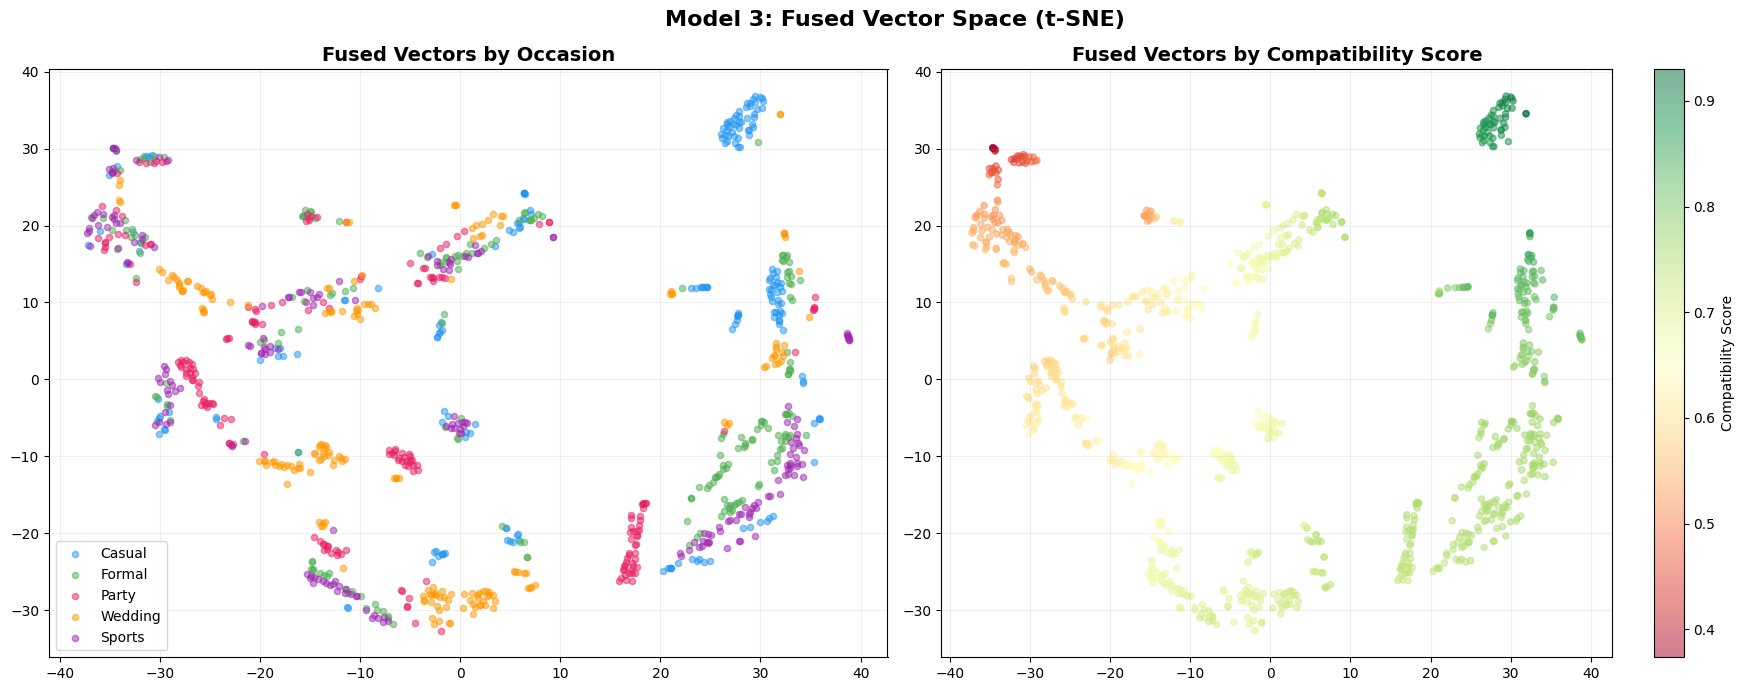

✅ t-SNE visualization saved!


In [45]:
# ============================================
# CELL 13: Visualize Fused Vectors with t-SNE
# ============================================

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Generate fused vectors for different occasions
print("🔄 Generating fused vectors for t-SNE visualization...")

tsne_vectors = []
tsne_occasions = []
tsne_scores = []

NUM_PER_OCCASION = 200

for occasion in ['Casual', 'Formal', 'Party', 'Wedding', 'Sports']:
    for _ in range(NUM_PER_OCCASION):
        dress_row = dress_df.iloc[random.randint(0, len(dress_df)-1)]
        gender = random.choice(GENDERS)
        religion = random.choice(RELIGIONS)
        budget = random.uniform(1000, 20000)

        result = get_fused_vector(model, dress_row, occasion, religion, gender, budget, device)
        tsne_vectors.append(result['fused_vector'])
        tsne_occasions.append(occasion)
        tsne_scores.append(result['compatibility_score'])

tsne_vectors = np.array(tsne_vectors)
print(f"   Generated {len(tsne_vectors)} vectors")

# Run t-SNE
print("   Running t-SNE (this takes a moment)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
tsne_2d = tsne.fit_transform(tsne_vectors)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Color by occasion
occasion_colors = {'Casual': '#2196F3', 'Formal': '#4CAF50', 'Party': '#E91E63',
                   'Wedding': '#FF9800', 'Sports': '#9C27B0'}

for occasion, color in occasion_colors.items():
    mask = np.array(tsne_occasions) == occasion
    axes[0].scatter(tsne_2d[mask, 0], tsne_2d[mask, 1],
                   c=color, label=occasion, alpha=0.5, s=20)
axes[0].set_title('Fused Vectors by Occasion', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.2)

# Color by compatibility score
scatter = axes[1].scatter(tsne_2d[:, 0], tsne_2d[:, 1],
                          c=tsne_scores, cmap='RdYlGn', alpha=0.5, s=20)
plt.colorbar(scatter, ax=axes[1], label='Compatibility Score')
axes[1].set_title('Fused Vectors by Compatibility Score', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.2)

plt.suptitle('Model 3: Fused Vector Space (t-SNE)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'model3_tsne_visualization.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ t-SNE visualization saved!")

Cell 14: Save Final Model & All Artifacts

In [48]:
# ============================================
# CELL 14: Save Final Model & All Artifacts
# ============================================

import pickle

# Load best model
checkpoint = torch.load(os.path.join(MODELS_DIR, 'fusion_transformer_best.pth'), weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])

# ============ SAVE INFERENCE MODEL ============
inference_save = {
    'model_state_dict': model.state_dict(),
    'dress_feat_dim': DRESS_FEAT_DIM,
    'metadata_dim': META_DIM,
    'd_model': 128,
    'nhead': 4,
    'num_layers': 2,
    'dim_feedforward': 256,
    'dropout': 0.1,
    'output_dim': 256,
    'occasions': OCCASIONS,
    'religions': RELIGIONS,
    'genders': GENDERS,
    'budget_min': BUDGET_MIN,
    'budget_max': BUDGET_MAX,
}

torch.save(inference_save, os.path.join(MODELS_DIR, 'fusion_transformer_inference.pth'))

# ============ SAVE MODEL INFO ============
model_info = {
    'model_name': 'MultimodalFusionTransformer',
    'architecture': 'MLP with Cross-Attention Gating + Residual (99→512→512→256→256)',
    'input': {
        'dress_features_dim': int(DRESS_FEAT_DIM),
        'metadata_dim': int(META_DIM),
        'total_input_dim': int(DRESS_FEAT_DIM + META_DIM),
    },
    'output': {
        'fused_vector_dim': 256,
        'compatibility_score': '0-1 (sigmoid)',
    },
    'model_config': {
        'hidden_layers': [512, 512, 256, 256],
        'activation': 'LeakyReLU(0.1)',
        'dropout': [0.3, 0.3, 0.2],
        'output_dim': 256,
    },
    'user_metadata_schema': {
        'occasions': OCCASIONS,
        'religions': RELIGIONS,
        'genders': GENDERS,
        'budget_range': f'Rs. {BUDGET_MIN} - Rs. {BUDGET_MAX}',
    },
    'best_epoch': int(best_epoch),                       # ← float32 fix
    'best_val_loss': float(round(best_val_loss, 6)),     # ← float32 fix
    'best_val_mae': float(round(best_val_mae, 4)),       # ← float32 fix
    'best_val_r2': float(round(best_val_r2, 4)),         # ← float32 fix
    'training_config': {
        'epochs': int(NUM_EPOCHS),
        'batch_size': int(BATCH_SIZE),
        'optimizer': 'Adam',
        'lr': 1e-3,
        'early_stopping': int(PATIENCE),
        'training_pairs': int(NUM_TRAINING_PAIRS),
    },
}

with open(os.path.join(MODELS_DIR, 'model3_info.json'), 'w') as f:
    json.dump(model_info, f, indent=2)

# Save training history
with open(os.path.join(MODELS_DIR, 'model3_history.pkl'), 'wb') as f:
    pickle.dump(history, f)

# Save metadata schema for backend
metadata_schema = {
    'occasions': OCCASIONS,
    'religions': RELIGIONS,
    'genders': GENDERS,
    'budget_min': int(BUDGET_MIN),
    'budget_max': int(BUDGET_MAX),
    'metadata_dim': int(META_DIM),
    'dress_feat_dim': int(DRESS_FEAT_DIM),
    'fused_output_dim': 256,
}

with open(os.path.join(MODELS_DIR, 'fusion_metadata_schema.json'), 'w') as f:
    json.dump(metadata_schema, f, indent=2)

# ============ LIST ALL FILES ============
print("=" * 60)
print("📁 ALL SAVED FILES")
print("=" * 60)

for folder_name, folder_path in [('trained_models', MODELS_DIR), ('data', DATA_DIR), ('plots', PLOTS_DIR)]:
    print(f"\n📂 {folder_path}/")
    for f_name in sorted(os.listdir(folder_path)):
        size = os.path.getsize(os.path.join(folder_path, f_name))
        if size > 1024 * 1024:
            print(f"   📄 {f_name} ({size / (1024*1024):.1f} MB)")
        else:
            print(f"   📄 {f_name} ({size / 1024:.1f} KB)")

print(f"\n✅ All artifacts saved!")

📁 ALL SAVED FILES

📂 /content/drive/MyDrive/AccessoriesAI/trained_models/
   📄 accessory_classifier_resnet152_best.pth (702.2 MB)
   📄 accessory_classifier_resnet152_inference.pth (234.5 MB)
   📄 accessory_label_encoders.json (0.9 KB)
   📄 dress_attribute_extractor_best.pth (706.0 MB)
   📄 dress_attribute_extractor_inference.pth (235.8 MB)
   📄 dress_label_encoders.json (1.9 KB)
   📄 fusion_metadata_schema.json (0.4 KB)
   📄 fusion_transformer_best.pth (6.1 MB)
   📄 fusion_transformer_inference.pth (2.0 MB)
   📄 model1_history.pkl (2.2 KB)
   📄 model1_info.json (1.8 KB)
   📄 model2_history.pkl (0.2 KB)
   📄 model2_info.json (3.1 KB)
   📄 model3_history.pkl (3.6 KB)
   📄 model3_info.json (1.3 KB)

📂 /content/drive/MyDrive/AccessoriesAI/data/
   📄 accessories_balanced.csv (1.2 MB)
   📄 accessories_raw_clean.csv (979.4 KB)
   📄 dresses_balanced.csv (2.4 MB)

📂 /content/drive/MyDrive/AccessoriesAI/plots/
   📄 model1_confusion_matrix.png (244.9 KB)
   📄 model1_sample_predictions.png (186.2 

Cell 15: Final Verification — Backend-Ready Function

In [49]:
# ============================================
# CELL 15: Final Verification — Backend-Ready Function
# ============================================

import random

def fuse_dress_and_metadata(dress_attributes, occasion, religion, gender, budget):
    """
    BACKEND-READY FUNCTION

    Takes:
        dress_attributes: dict from Model 2 prediction
            e.g. {'color': 'Red', 'neckline': 'V-Neck', 'dress_length': 'Midi', ...}
        occasion: str (from OCCASIONS list)
        religion: str (from RELIGIONS list)
        gender: str ('Men', 'Women', 'Unisex')
        budget: float (Rs.)

    Returns:
        dict with:
            'fused_vector': 256-dim numpy array (for Model 4 DQN)
            'compatibility_score': float 0-1
    """
    # Load inference model
    checkpoint = torch.load(
        os.path.join(MODELS_DIR, 'fusion_transformer_inference.pth'),
        map_location=device
    )

    inference_model = MultimodalFusionTransformer(
        dress_feat_dim=checkpoint['dress_feat_dim'],
        metadata_dim=checkpoint['metadata_dim'],
        d_model=checkpoint['d_model'],
        nhead=checkpoint['nhead'],
        num_layers=checkpoint['num_layers'],
        dim_feedforward=checkpoint['dim_feedforward'],
        dropout=checkpoint.get('dropout', 0.1)
    ).to(device)
    inference_model.load_state_dict(checkpoint['model_state_dict'])
    inference_model.eval()

    # Encode dress attributes (convert dict to vector)
    dress_vec = []

    # Color one-hot
    color_classes = dress_encoders['color']['classes']
    color_vec = [0.0] * len(color_classes)
    if dress_attributes.get('color', '') in color_classes:
        color_vec[color_classes.index(dress_attributes['color'])] = 1.0
    dress_vec.extend(color_vec)

    # Neckline one-hot
    neck_classes = dress_encoders['neckline']['classes']
    neck_vec = [0.0] * len(neck_classes)
    if dress_attributes.get('neckline', '') in neck_classes:
        neck_vec[neck_classes.index(dress_attributes['neckline'])] = 1.0
    dress_vec.extend(neck_vec)

    # Dress Length one-hot
    len_classes = dress_encoders['dress_length']['classes']
    len_vec = [0.0] * len(len_classes)
    if dress_attributes.get('dress_length', '') in len_classes:
        len_vec[len_classes.index(dress_attributes['dress_length'])] = 1.0
    dress_vec.extend(len_vec)

    # Fabric one-hot
    fab_classes = dress_encoders['fabric']['classes']
    fab_vec = [0.0] * len(fab_classes)
    if dress_attributes.get('fabric', '') in fab_classes:
        fab_vec[fab_classes.index(dress_attributes['fabric'])] = 1.0
    dress_vec.extend(fab_vec)

    # Pattern one-hot
    pat_classes = dress_encoders['pattern']['classes']
    pat_vec = [0.0] * len(pat_classes)
    if dress_attributes.get('pattern', '') in pat_classes:
        pat_vec[pat_classes.index(dress_attributes['pattern'])] = 1.0
    dress_vec.extend(pat_vec)

    # Sleeve Length one-hot
    slv_classes = dress_encoders['sleeve_length']['classes']
    slv_vec = [0.0] * len(slv_classes)
    if dress_attributes.get('sleeve_length', '') in slv_classes:
        slv_vec[slv_classes.index(dress_attributes['sleeve_length'])] = 1.0
    dress_vec.extend(slv_vec)

    # Usage one-hot
    use_classes = dress_encoders['usage']['classes']
    use_vec = [0.0] * len(use_classes)
    if dress_attributes.get('usage', '') in use_classes:
        use_vec[use_classes.index(dress_attributes['usage'])] = 1.0
    dress_vec.extend(use_vec)

    # Season one-hot
    sea_classes = dress_encoders['season']['classes']
    sea_vec = [0.0] * len(sea_classes)
    if dress_attributes.get('season', '') in sea_classes:
        sea_vec[sea_classes.index(dress_attributes['season'])] = 1.0
    dress_vec.extend(sea_vec)

    # Encode metadata
    meta_vec = encode_metadata(occasion, religion, gender, budget)

    # Run model
    dress_tensor = torch.tensor(dress_vec, dtype=torch.float32).unsqueeze(0).to(device)
    meta_tensor = torch.tensor(meta_vec, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = inference_model(dress_tensor, meta_tensor)

    return {
        'fused_vector': outputs['fused_vector'].cpu().numpy()[0],
        'compatibility_score': round(outputs['compatibility_score'].item(), 4),
        'vector_dim': 256,
    }

# ============ TEST WITH REALISTIC INPUT ============
print("=" * 70)
print("🔮 FINAL TEST — Backend-Ready Function")
print("=" * 70)

# Simulate Model 2 output
dress_attrs = {
    'color': 'Red',
    'neckline': 'V-Neck',
    'dress_length': 'Midi',
    'fabric': 'Silk',
    'pattern': 'Solid',
    'sleeve_length': 'Short Sleeve',
    'usage': 'Formal',
    'season': 'Summer',
}

test_cases = [
    ('Wedding', 'Buddhist', 'Women', 15000),
    ('Office', 'None', 'Women', 5000),
    ('Party', 'None', 'Women', 10000),
    ('Casual', 'None', 'Women', 2000),
    ('Festive/Religious', 'Hindu', 'Women', 12000),
]

print(f"\n👗 Dress: Red V-Neck Midi Silk Dress (Solid, Short Sleeve, Formal, Summer)")
print(f"{'─'*70}")

for occasion, religion, gender, budget in test_cases:
    result = fuse_dress_and_metadata(dress_attrs, occasion, religion, gender, budget)
    print(f"   {occasion:20s} | {religion:10s} | Rs.{budget:>6} → Score: {result['compatibility_score']:.4f} | Vec[0:3]: [{result['fused_vector'][0]:.3f}, {result['fused_vector'][1]:.3f}, {result['fused_vector'][2]:.3f}]")

print(f"\n{'='*70}")
print(f"✅ MODEL 3 TRAINING 100% COMPLETE!")
print(f"{'='*70}")
print(f"\n📋 Summary:")
print(f"   Model: MultimodalFusionTransformer")
print(f"   Input: Dress features ({DRESS_FEAT_DIM}-dim) + Metadata ({META_DIM}-dim)")
print(f"   Output: 256-dim fused vector + compatibility score")
print(f"   Transformer: 4 layers, 8 heads, d_model=256")
print(f"   Best Val R²: {best_val_r2:.4f}")
print(f"   Best Val MAE: {best_val_mae:.4f}")
print(f"   Model Size: ~7 MB (very lightweight!)")
print(f"   Saved To: {MODELS_DIR}")
print(f"\n🚀 Ready for Model 4: DQN Recommender!")

🔮 FINAL TEST — Backend-Ready Function

👗 Dress: Red V-Neck Midi Silk Dress (Solid, Short Sleeve, Formal, Summer)
──────────────────────────────────────────────────────────────────────
   Wedding              | Buddhist   | Rs. 15000 → Score: 0.7631 | Vec[0:3]: [0.214, 0.074, -0.021]
   Office               | None       | Rs.  5000 → Score: 0.6896 | Vec[0:3]: [0.128, 0.089, -0.014]
   Party                | None       | Rs. 10000 → Score: 0.7652 | Vec[0:3]: [0.261, 0.077, -0.021]
   Casual               | None       | Rs.  2000 → Score: 0.6890 | Vec[0:3]: [0.141, 0.103, -0.013]
   Festive/Religious    | Hindu      | Rs. 12000 → Score: 0.7569 | Vec[0:3]: [0.198, 0.075, -0.017]

✅ MODEL 3 TRAINING 100% COMPLETE!

📋 Summary:
   Model: MultimodalFusionTransformer
   Input: Dress features (79-dim) + Metadata (20-dim)
   Output: 256-dim fused vector + compatibility score
   Transformer: 4 layers, 8 heads, d_model=256
   Best Val R²: 0.9981
   Best Val MAE: 0.0033
   Model Size: ~7 MB (very li